# Zadanie 1
## Klasyfikacja Absorbcja/Dystrybucja

| Task | Description |
|------|-------------|
| hia_hou | Absorption |
| bioavailability_ma | Absorption |
| bbb_martins | Distribution |

Brak wspólnych smiles bbb_martins i hia_hou


In [1]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt

import random_forest_model
# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['hia_hou', 'bioavailability_ma', 'bbb_martins']
df = df[df['task'].isin(tasks)]

df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [2]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
bbb_martins           2030
bioavailability_ma     640
hia_hou                578
Name: count, dtype: int64
Średnia liczba zadań na smiles: 1.16


,task,bbb_martins,bioavailability_ma,hia_hou,mean,count,std
0,bbb_martins,1975,293,90,0.764039,2030,0.424702
1,bioavailability_ma,293,640,129,0.768750,640,0.421962
2,hia_hou,90,129,578,0.865052,578,0.341964


In [3]:
mask = df.groupby('smiles')['task'].transform('nunique') > 1
duplicated_rows = df[df.groupby('smiles')['task'].transform('nunique') > 1].sort_values('smiles')

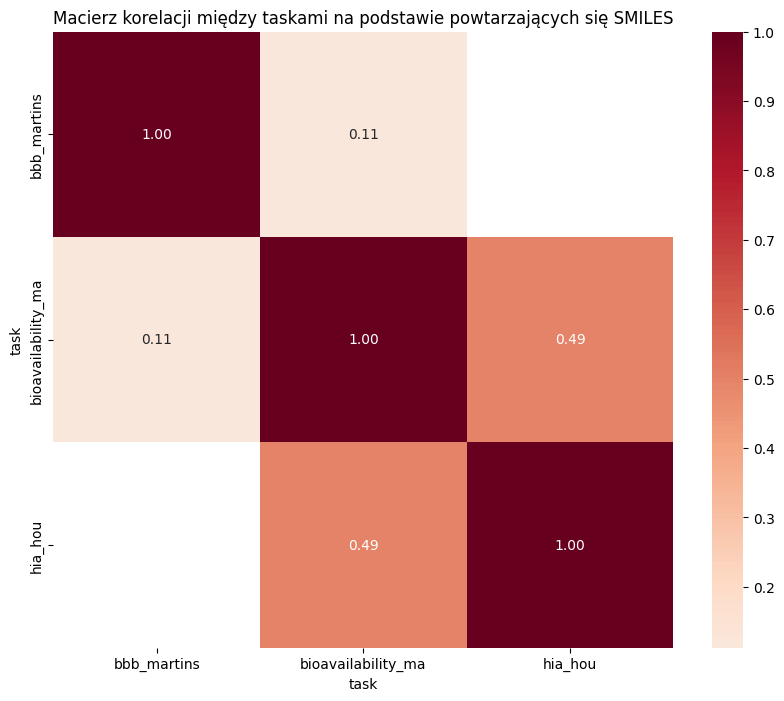

In [4]:
corr_matrix = df_wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Macierz korelacji między taskami na podstawie powtarzających się SMILES')
plt.show()

NaN wynika z braku wariancji w części wspólnej hia_hou (absorbcja) i bbb_martins (dystrybucja). W każdym przypadku jeśli badano oba związki to absorbcja wynosiła True.

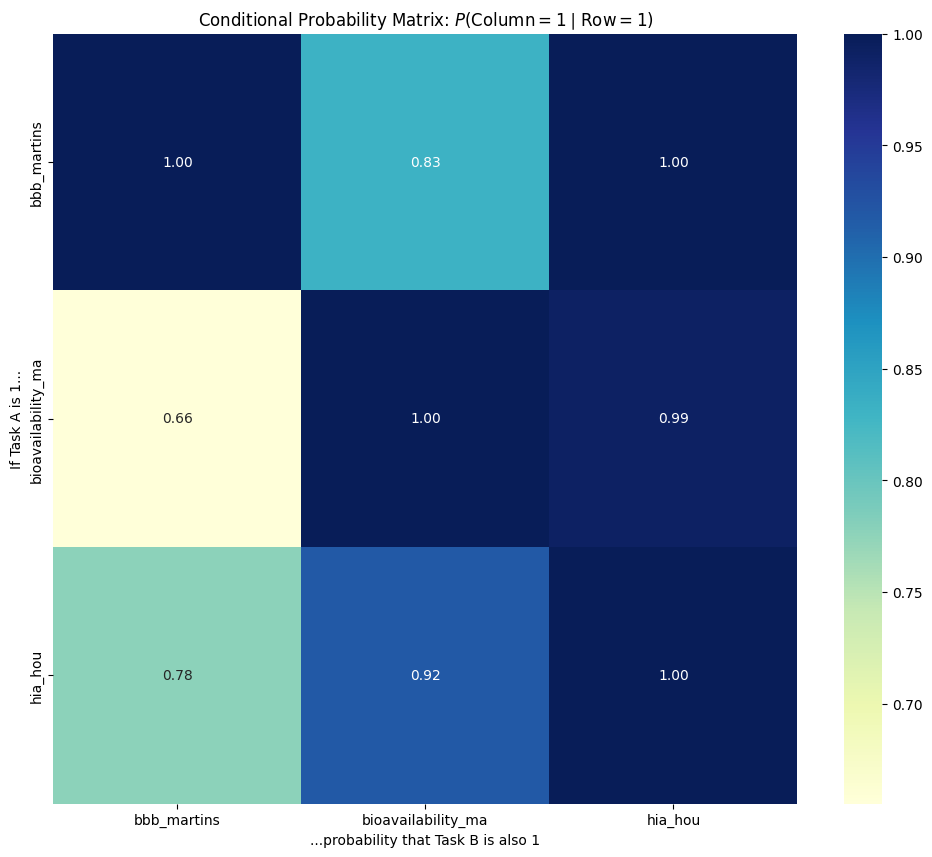

In [5]:
ones_mask = (df_wide == 1).astype(int)
intersection_11 = ones_mask.T @ ones_mask

valid_mask = df_wide.notna().astype(int)
intersection_1x = ones_mask.T @ valid_mask

cond_prob = intersection_11 / intersection_1x

plt.figure(figsize=(12, 10))
sns.heatmap(cond_prob, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Conditional Probability Matrix: $P(\\text{Column}=1 \\mid \\text{Row}=1)$")
plt.ylabel("If Task A is 1...")
plt.xlabel("...probability that Task B is also 1")
plt.show()

In [6]:
summary_df = random_forest_model.run_single_task_pipeline(df, tasks)
summary_df['SOTA acc'] = ['0.989±0.001', '0.748±0.033', '0.916±0.001']
summary_df

,task,auc,acc,f1,SOTA acc
0,hia_hou,0.943570,0.905172,0.946341,0.989±0.001
1,bioavailability_ma,0.694006,0.726562,0.834123,0.748±0.033
2,bbb_martins,0.899003,0.857143,0.910217,0.916±0.001



SOTA results from paper "Quantum Enhanced MTL ...".


In our model used RandomForestClassifier from scikit with 200 estimators.